# Lab 4 : Missing Data Handling in R

Dataset: Adult Census dataset (2000 row sample)



In [1]:
adult <- read.csv("adult.csv")
str(adult)

'data.frame':	32561 obs. of  15 variables:
 $ age           : int  90 82 66 54 41 34 38 74 68 41 ...
 $ workclass     : chr  "?" "Private" "?" "Private" ...
 $ fnlwgt        : int  77053 132870 186061 140359 264663 216864 150601 88638 422013 70037 ...
 $ education     : chr  "HS-grad" "HS-grad" "Some-college" "7th-8th" ...
 $ education.num : int  9 9 10 4 10 9 6 16 9 10 ...
 $ marital.status: chr  "Widowed" "Widowed" "Widowed" "Divorced" ...
 $ occupation    : chr  "?" "Exec-managerial" "?" "Machine-op-inspct" ...
 $ relationship  : chr  "Not-in-family" "Not-in-family" "Unmarried" "Unmarried" ...
 $ race          : chr  "White" "White" "Black" "White" ...
 $ sex           : chr  "Female" "Female" "Female" "Female" ...
 $ capital.gain  : int  0 0 0 0 0 0 0 0 0 0 ...
 $ capital.loss  : int  4356 4356 4356 3900 3900 3770 3770 3683 3683 3004 ...
 $ hours.per.week: int  40 18 40 40 40 45 40 20 40 60 ...
 $ native.country: chr  "United-States" "United-States" "United-States" "United-States" 

In [2]:
install.packages("naniar")
install.packages("skimr")
library(naniar)
library(skimr)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gridExtra’, ‘plyr’, ‘norm’, ‘visdat’, ‘viridis’, ‘UpSetR’


Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)


Attaching package: ‘skimr’


The following object is masked from ‘package:naniar’:

    n_complete




In [9]:
set.seed(42)

n <- nrow(adult)

# Check column names and find the hours column automatically
hours_col <- names(adult)[tolower(gsub("[^a-z]", "", names(adult))) == "hoursperweek"]

if (length(hours_col) == 0) {
  stop("Could not find the hours-per-week column. Run names(adult) to check the column names.")
}

# Convert numeric columns
adult$age <- as.numeric(adult$age)
adult[[hours_col]] <- as.numeric(adult[[hours_col]])

# Create pool of row indices
all_indices <- 1:n

# Select unique indices
na_index <- sample(all_indices, 6)
all_indices <- setdiff(all_indices, na_index)

blank_index <- sample(all_indices, 6)
all_indices <- setdiff(all_indices, blank_index)

nan_index <- sample(all_indices, 4)
all_indices <- setdiff(all_indices, nan_index)

wrong_index <- sample(all_indices, 4)

# Introduce errors
adult$age[na_index] <- NA
adult$workclass[blank_index] <- ""
adult[[hours_col]][nan_index] <- NA
adult$age[wrong_index] <- 999

# Save dirty dataset
write.csv(adult, "adult_dirty_data.csv", row.names = FALSE)

In [10]:
sum(is.na(adult$age))
sum(is.nan(adult$hours_per_week))

x <- NULL
is.null(x)

sum(adult$workclass == "")
sum(adult$age == 999, na.rm = TRUE)

miss_var_summary(adult)

[1] 6

[1] 0

[1] TRUE

[1] 6

[1] 4

variable,n_miss,pct_miss
<chr>,<int>,<num>
age,6,0.018[4m4[24m
hours.per.week,4,0.012[4m3[24m
workclass,0,0
fnlwgt,0,0
education,0,0
education.num,0,0
marital.status,0,0
occupation,0,0
relationship,0,0


In [11]:
adult$age[adult$age == 999] <- NA
adult$workclass[adult$workclass == ""] <- "Unknown"

med_age <- median(adult$age, na.rm = TRUE)
adult$age[is.na(adult$age)] <- med_age

adult <- adult[!is.nan(adult$hours_per_week), ]

sum(complete.cases(adult))

[1] 0

In [12]:
impute_median <- function(x){
  med <- median(x, na.rm = TRUE)
  x[is.na(x)] <- med
  return(x)
}

test <- c(10, 20, NA, 40, NA, 60)
impute_median(test)

adult$hours_per_week <- impute_median(adult$hours_per_week)

[1] 10 20 30 40 30 60

[1] 20
[1] 0


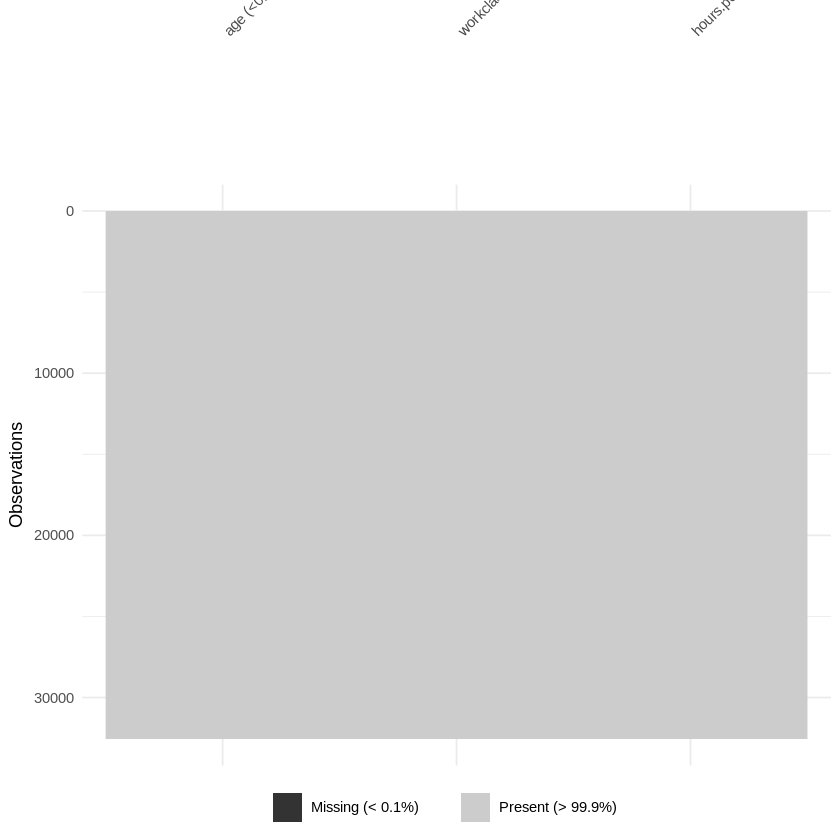

In [16]:
dirty <- read.csv("adult_dirty_data.csv", stringsAsFactors = FALSE)

# Find hours-per-week column
hours_col <- names(dirty)[
  tolower(gsub("[^a-z]", "", names(dirty))) == "hoursperweek"
]

# Check error counts
before <- sum(is.na(dirty$age)) +
          sum(dirty$workclass == "") +
          sum(is.na(dirty[[hours_col]])) +
          sum(dirty$age == 999, na.rm = TRUE)

after <- sum(is.na(adult$age)) +
         sum(adult$workclass == "") +
         sum(is.na(adult[[hours_col]])) +
         sum(adult$age == 999, na.rm = TRUE)

print(before)
print(after)

# Visualize missing values separately
vis_miss(dirty[, c("age", "workclass", hours_col)])

In [17]:
skim(adult)

any(adult$age == 999)
any(is.na(adult$age))
any(adult$workclass == "")
any(is.nan(adult$hours_per_week))

write.csv(adult, "cleaned_adult_data.csv", row.names = FALSE)

,skim_type,skim_variable,n_missing,complete_rate,character.min,character.max,character.empty,character.n_unique,character.whitespace,numeric.mean,numeric.sd,numeric.p0,numeric.p25,numeric.p50,numeric.p75,numeric.p100,numeric.hist
,<chr>,<chr>,<int>,<dbl>,<lgl>,<lgl>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,character,workclass,0,NaN,NA,NA,0,0,0,NA,NA,NA,NA,NA,NA,NA,NA
2,character,education,0,NaN,NA,NA,0,0,0,NA,NA,NA,NA,NA,NA,NA,NA
3,character,marital.status,0,NaN,NA,NA,0,0,0,NA,NA,NA,NA,NA,NA,NA,NA
4,character,occupation,0,NaN,NA,NA,0,0,0,NA,NA,NA,NA,NA,NA,NA,NA
5,character,relationship,0,NaN,NA,NA,0,0,0,NA,NA,NA,NA,NA,NA,NA,NA
6,character,race,0,NaN,NA,NA,0,0,0,NA,NA,NA,NA,NA,NA,NA,NA
7,character,sex,0,NaN,NA,NA,0,0,0,NA,NA,NA,NA,NA,NA,NA,NA
8,character,native.country,0,NaN,NA,NA,0,0,0,NA,NA,NA,NA,NA,NA,NA,NA
9,character,income,0,NaN,NA,NA,0,0,0,NA,NA,NA,NA,NA,NA,NA,NA


[1] FALSE

[1] FALSE

[1] FALSE

[1] FALSE

Conclusion: Before cleaning the data had 16 missing or wrong values spread across age, workclass and hours_per_week. After cleaning all of them are gone - age was filled in with the median, blank workclass values became "Unknown", and the rows with NaN hours were dropped. NA, NaN, NULL and "" all mean something different in R, so each one needed its own fix.